### Logistic Regression with single feature

### Background

Artificial Intelligence (AI), Machine Learning (ML), Deep Learning (DL), and Data Science are interconnected fields used to extract insights from data and build intelligent systems.

AI: Broad field that enables machines to mimic human intelligence.
ML: Subfield of AI where models learn patterns from data.
DL: Subset of ML using neural networks with multiple layers.
Data Science: Focuses on analyzing and interpreting data using statistical and computational methods.

In this task, we apply Machine Learning (Logistic Regression) to predict heart disease using patient cholesterol levels.

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score, ConfusionMatrixDisplay

### 1. Data Retrieval and Collection

In [2]:
def load_data(filepath):
    df = pd.read_csv(filepath)
    return df

In [5]:
df = load_data(filepath='Heart_Disease_Prediction.csv')

In [6]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [7]:
df.shape

(270, 14)

In [8]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


This dataset contains health-related information used to predict whether a patient has heart disease based on medical measurements. It includes various clinical attributes such as cholesterol levels, blood pressure, age, and other health indicators that help in identifying the risk of heart disease.
The meaning of those indicators are:
1. Sex: 0=femle,1=male
2. Chest pain type: 1=Typical Angina, 2=Atypical Angina , 3=Non agninal pain, 4=asymtomatic
3. Slope of ST: 1=upsloping, 2=flat,3=downsloping

### 2. Data Cleaning

In [9]:
df.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [10]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
265    False
266    False
267    False
268    False
269    False
Length: 270, dtype: bool

In [11]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# determine the dataset
df.dtypes

Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease                  str
dtype: object

### 3. Feature Design

In [14]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore"
)

In [ ]:
df['Heart Disease Num'] = df['Heart Disease'].map({
    'Absence': 0,
    'Presence': 1
})

In [25]:
correlation = df['Cholesterol'].corr(df['Heart Disease Num'])
print("Correlation with target:", correlation)

Correlation with target: 0.11802053060516998


Selected Feature:
Input (X): Cholesterol
Target (Y): HeartDisease

Cholesterol is an important medical indicator because high cholesterol levels can lead to plaque buildup in arteries, increasing the risk of heart disease. Therefore, it is a relevant predictor for cardiovascular conditions.

In [43]:
X=df[['Cholesterol']]
Y=df['Heart Disease Num']

### 4. Algorithm Selection

Chosen Model: Logistic Regression
Logistic Regression is suitable because:

It is designed for binary classification problems
It predicts probabilities between 0 and 1
It uses a sigmoid function to map outputs to classes (0 or 1)


### 5. Loss Function Selection
Loss Function: Binary Cross-Entropy (Log Loss)

Formula: Loss=−[ylog(p)+(1−y)log(1−p)]

Binary Cross-Entropy measures the difference between:

Actual labels (0 or 1) and Predicted probabilities

It penalizes incorrect predictions more when the model is confident but wrong. Lower log loss means better performance.

### 6. Model Learning(training)

Split dataset into:
1. Training set (e.g., 80%)
2. Testing set (e.g., 20%)

Train Logistic Regression model using training data

The model learns:

1. A weight (coefficient) for cholesterol
2. A bias (intercept)

It adjusts these parameters using optimization techniques (like gradient descent or solver methods) to minimize the log loss.

In [44]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.3, random_state=42, stratify=Y)

In [45]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((189, 1), (81, 1), (189,), (81,))

##### Training model

In [46]:
x_train_scaled = StandardScaler().fit_transform(x_train)
x_test_scaled = StandardScaler().fit_transform(x_test)
print("trained_scaled: ", x_train_scaled[:3])
print("test_scaled: ", x_test_scaled[:3])

trained_scaled:  [[-0.71738509]
 [-1.2997821 ]
 [-0.07862708]]
test_scaled:  [[-0.58308374]
 [-0.64685032]
 [ 0.98982532]]


In [ ]:
logistic_model = LogisticRegression(C=np.inf, random_state=42)
logistic_model.fit(x_train_scaled, y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",inf
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [48]:
logistic_model.coef_

array([[0.14315357]])

In [49]:
y_pred = logistic_model.predict(x_test_scaled)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

In [50]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.56      0.96      0.70        45
           1       0.50      0.06      0.10        36

    accuracy                           0.56        81
   macro avg       0.53      0.51      0.40        81
weighted avg       0.53      0.56      0.44        81



Confusion Matrix
[[43  2]
 [34  2]]


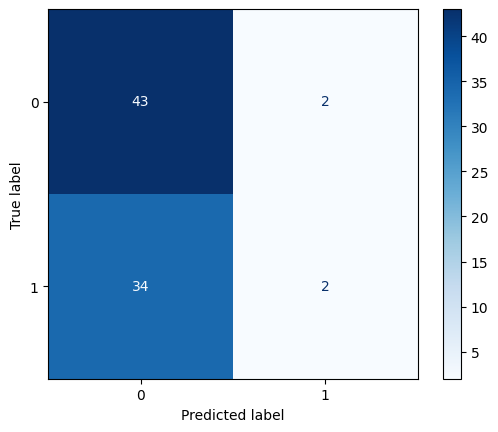

In [51]:
print("Confusion Matrix")
confusion_mat = confusion_matrix(y_true=y_test, y_pred=y_pred)
ConfusionMatrixDisplay(confusion_matrix=confusion_mat).plot(cmap="Blues")
print(confusion_mat)

In [52]:
y_score = logistic_model.predict_proba(x_test_scaled)[:, 1]

### 7. Model Evaluation

In [53]:
from sklearn.metrics import (accuracy_score, precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.5555555555555556
Precision: 0.5
Recall: 0.05555555555555555
F1 Score: 0.1


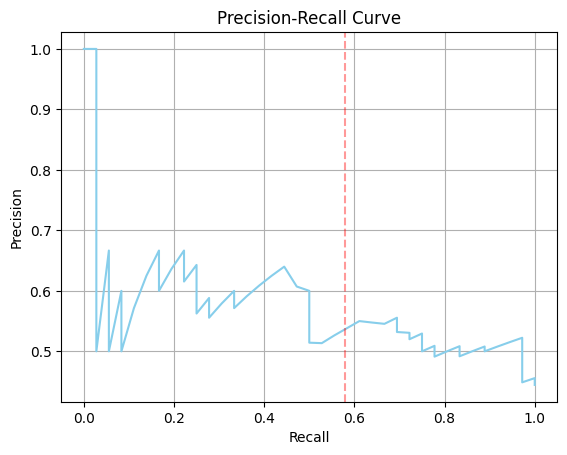

Average Precision Score: 0.580


In [56]:
from sklearn.metrics import precision_recall_curve, average_precision_score
precision, recall, _ = precision_recall_curve(y_test, y_score)
pr_auc = average_precision_score(y_test, y_score)
plt.plot(recall, precision, color='skyblue')
plt.axvline(pr_auc, color='r', alpha=0.4, linestyle='--')
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.show()
print(f"Average Precision Score: {pr_auc:.3f}")